In [4]:

import glob
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from scipy.stats import kstest, mannwhitneyu, ranksums, ttest_ind
from statsmodels.stats.multitest import fdrcorrection, multipletests

%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm

mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")

from sklearn.impute import SimpleImputer

# Fig2A

In [2]:
pvalue_sALS_ctrl = pd.read_pickle(
    "./sALS_ctrl_pvalue.pkl"
)

pvalue_sALS_ctrl = pd.DataFrame(pvalue_sALS_ctrl).set_index(0)

pvalue_sALS_ctrl.columns = ["ks", "ranksums", "mw", "ttest"]

In [6]:
temp_sals_ctrl_heatmap = pvalue_sALS_ctrl.iloc[:, [0]]
temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap.dropna()
temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap[temp_sals_ctrl_heatmap['ks'] <
                                                0.05]

temp_sals_ctrl_heatmap[
    'diff'] = temp_merged.iloc[:, (temp_merged.columns.str.startswith('sALS'))
                               & (temp_merged.columns != 'sALS_32')].mean(
                                   axis=1
                               ) - temp_merged.iloc[:,
                                                    temp_merged.columns.str.
                                                    startswith('Control'
                                                               )].mean(axis=1)
temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap[temp_sals_ctrl_heatmap['diff']
                                                != 0]
temp_sals_ctrl_heatmap['score'] = -np.log10(
    temp_sals_ctrl_heatmap['ks']) * temp_sals_ctrl_heatmap['diff'].abs()

temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap.iloc[~temp_sals_ctrl_heatmap.
                                                     index.str.startswith(
                                                         ('chrX', 'chrY'))]

temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap.iloc[[
    len(_.split('_')) == 2 for _ in temp_sals_ctrl_heatmap.index
]]

# only keep CpGs have valid values for more than 80% of samples in each groups
temp_sals_ctrl_heatmap["sALS_validCpG"] = (
    ~(
        temp_merged.loc[
            temp_sals_ctrl_heatmap.index,
            (temp_merged.columns.str.startswith("sALS"))
            & (temp_merged.columns != "sALS_32"),
        ].isna()
    )
).sum(axis=1)
temp_sals_ctrl_heatmap["Ctrl_validCpG"] = (
    ~(
        temp_merged.loc[
            temp_sals_ctrl_heatmap.index, temp_merged.columns.str.startswith("Control")
        ].isna()
    )
).sum(axis=1)
temp_sals_ctrl_heatmap = temp_sals_ctrl_heatmap[
    (temp_sals_ctrl_heatmap["sALS_validCpG"] >= 19 * 0.8)
    & (temp_sals_ctrl_heatmap["Ctrl_validCpG"] >= 21 * 0.8)
].sort_values(by="score", ascending=False)

temp_heatmap_df = (
    temp_merged.loc[temp_sals_ctrl_heatmap.head(1000).index].iloc[
        :,
        (temp_merged.columns.str.startswith(("Control", "sALS")))
        & (temp_merged.columns != "sALS_32"),
    ]
    / 100
)
temp_heatmap_df = pd.DataFrame(
    SimpleImputer().fit_transform(temp_heatmap_df.T).T,
    index=temp_heatmap_df.index,
    columns=temp_heatmap_df.columns,
)

#temp_heatmap_df.to_csv(
#    "./Fig.2A.value.csv",
#    index=True,
#    header=True,
#)

In [5]:
temp_heatmap_df = pd.read_csv("./Fig.2A.value.csv", index_col=0)

Text(0.5, 1.0, 'β')

Text(0.5, 38.444444444444436, 'Sample')

Text(307.0555555555555, 0.5, 'CpG')

Text(8, -5, 'Control')

Text(29, -5, 'sALS')

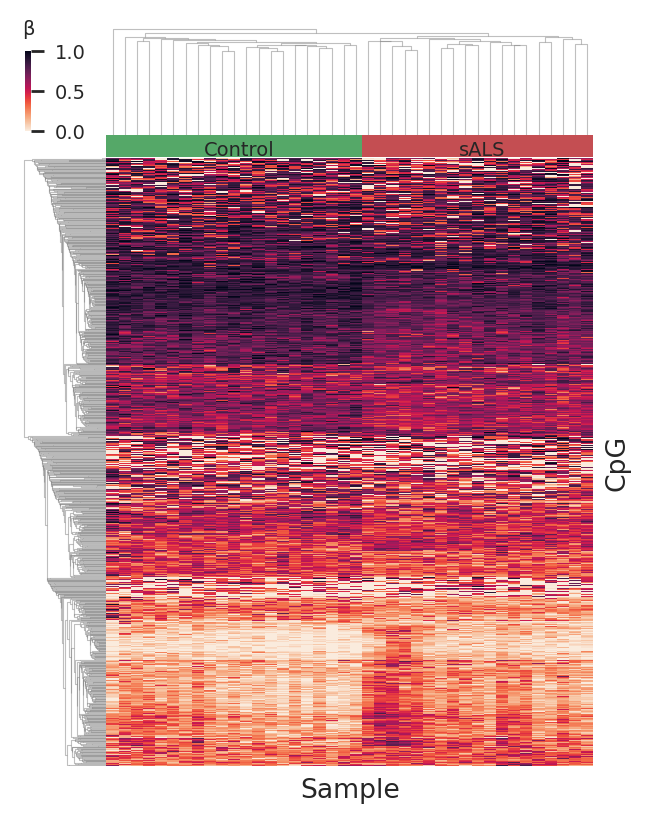

In [32]:

mpl.rcParams['font.family'] = 'Arial'
sns.set(context="paper", style="ticks")

ax = sns.clustermap(
    temp_heatmap_df,
    col_colors=[
        "g" if _.startswith("Control") else "r" for _ in temp_heatmap_df.columns
    ],
    yticklabels=False,
    xticklabels=False,
    cbar_pos=(0.05, 0.83, 0.01, 0.1),
    cmap="rocket_r",
    figsize=(3.35, 4),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.15, 0.15),
)

# --- fade the cluster trees (dendrograms) ---
for ax_ in [ax.ax_row_dendrogram, ax.ax_col_dendrogram]:
    for coll in ax_.collections:  # each is a LineCollection
        coll.set_alpha(0.5)  # transparency: 0 = invisible, 1 = solid
        coll.set_linewidth(0.4)  # (optional) thinner lines
        coll.set_color("gray")  # (optional) softer color
#ax.title.set_fontsize(8)
#ax.xaxis.label.set_fontsize(8)
#ax.yaxis.label.set_fontsize(8)
# optional: tick labels too
ax.tick_params(axis="both", labelsize=7)

ax.ax_cbar.set_title("β",fontsize=7)
ax.ax_heatmap.set_xlabel("Sample")
ax.ax_heatmap.set_ylabel("CpG")

ax.ax_heatmap.text(8, -5, "Control", fontdict={"size": 7})
ax.ax_heatmap.text(29, -5, "sALS", fontdict={"size": 7})
ax.savefig(
    "./Fig.2A.png",
    bbox_inches="tight",
    dpi=600,
)

Text(0.5, 1.0, 'β')

Text(0.5, 38.444444444444436, 'Sample')

Text(271.05555555555554, 0.5, 'CpG')

Text(8, -5, 'Control')

Text(29, -5, 'sALS')

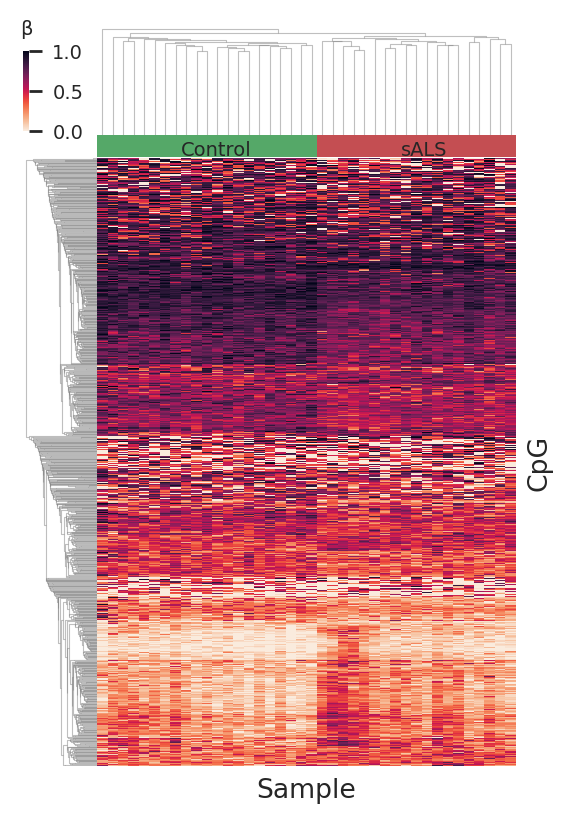

In [98]:

mpl.rcParams['font.family'] = 'Arial'
sns.set(context="paper", style="ticks")

ax = sns.clustermap(
    temp_heatmap_df,
    col_colors=[
        "g" if _.startswith("Control") else "r" for _ in temp_heatmap_df.columns
    ],
    yticklabels=False,
    xticklabels=False,
    cbar_pos=(0.05, 0.83, 0.01, 0.1),
    cmap="rocket_r",
    figsize=(2.95, 4),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.15, 0.15),
)

# --- fade the cluster trees (dendrograms) ---
for ax_ in [ax.ax_row_dendrogram, ax.ax_col_dendrogram]:
    for coll in ax_.collections:  # each is a LineCollection
        coll.set_alpha(0.5)  # transparency: 0 = invisible, 1 = solid
        coll.set_linewidth(0.4)  # (optional) thinner lines
        coll.set_color("gray")  # (optional) softer color
#ax.title.set_fontsize(8)
#ax.xaxis.label.set_fontsize(8)
#ax.yaxis.label.set_fontsize(8)
# optional: tick labels too
ax.tick_params(axis="both", labelsize=7)

ax.ax_cbar.set_title("β",fontsize=7)
ax.ax_heatmap.set_xlabel("Sample")
ax.ax_heatmap.set_ylabel("CpG")

ax.ax_heatmap.text(8, -5, "Control", fontdict={"size": 7})
ax.ax_heatmap.text(29, -5, "sALS", fontdict={"size": 7})
ax.savefig(
    "./Fig.2A_narrow.png",
    bbox_inches="tight",
    dpi=600,
)

# Fig2B

In [34]:
C9ALS_ctrl_p = pd.read_pickle(
    "./C9ALS_ctrl_pvalue.pkl"
)
C9ALS_ctrl_p = pd.DataFrame(C9ALS_ctrl_p).set_index(0)
C9ALS_ctrl_p.columns = ["ks", "ranksums", "mw", "ttest"]

In [ ]:
temp_c9als_ctrl_heatmap = C9ALS_ctrl_p.iloc[:, [0]]
temp_c9als_ctrl_heatmap = temp_c9als_ctrl_heatmap.dropna()
temp_c9als_ctrl_heatmap = temp_c9als_ctrl_heatmap[temp_c9als_ctrl_heatmap["ks"] < 0.05]
temp_c9als_ctrl_heatmap["diff"] = temp_merged.iloc[
    :, temp_merged.columns.str.startswith("C9-Patient")
].mean(axis=1) - temp_merged.iloc[
    :, temp_merged.columns.str.startswith("Control")
].mean(
    axis=1
)
temp_c9als_ctrl_heatmap = temp_c9als_ctrl_heatmap[temp_c9als_ctrl_heatmap["diff"] != 0]
temp_c9als_ctrl_heatmap["score"] = (
    -np.log10(temp_c9als_ctrl_heatmap["ks"]) * temp_c9als_ctrl_heatmap["diff"].abs()
)
temp_heatmap_df = (
    temp_merged.loc[temp_c9als_ctrl_heatmap.head(1000).index].iloc[
        :, temp_merged.columns.str.startswith(("Control", "C9-Patient"))
    ]
    / 100
)

temp_heatmap_df = pd.DataFrame(
    SimpleImputer().fit_transform(temp_heatmap_df.T).T,
    index=temp_heatmap_df.index,
    columns=temp_heatmap_df.columns,
)

temp_heatmap_df.to_csv(
    "./Fig.2B.value.csv",
    index=True,
    header=True,
)

Text(0.5, 1.0, 'β')

Text(0.5, 38.444444444444436, 'Sample')

Text(307.0555555555555, 0.5, 'CpG')

Text(3, -5, 'C9ALS')

Text(18.5, -5, 'Control')

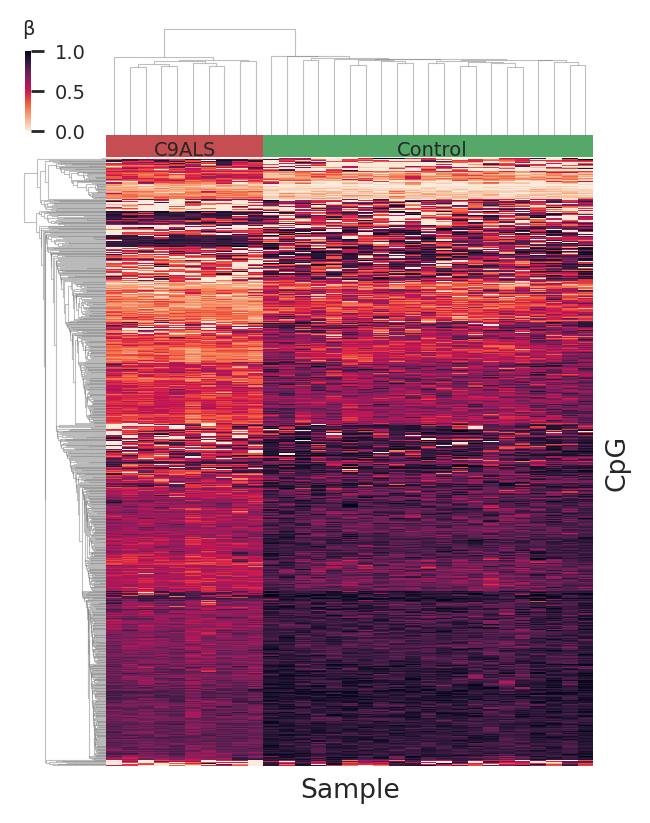

In [100]:
temp_heatmap_df = pd.read_csv("./Fig.2B.value.csv", index_col=0)




mpl.rcParams['font.family'] = 'Arial'
sns.set(context="paper", style="ticks")

ax = sns.clustermap(
    temp_heatmap_df,
    col_colors=[
        "g" if _.startswith("Control") else "r" for _ in temp_heatmap_df.columns
    ],
    yticklabels=False,
    xticklabels=False,
    cbar_pos=(0.05, 0.83, 0.01, 0.1),
    cmap="rocket_r",
    figsize=(3.35, 4),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.15, 0.15),
)

# --- fade the cluster trees (dendrograms) ---
for ax_ in [ax.ax_row_dendrogram, ax.ax_col_dendrogram]:
    for coll in ax_.collections:  # each is a LineCollection
        coll.set_alpha(0.5)  # transparency: 0 = invisible, 1 = solid
        coll.set_linewidth(0.4)  # (optional) thinner lines
        coll.set_color("gray")  # (optional) softer color
#ax.title.set_fontsize(8)
#ax.xaxis.label.set_fontsize(8)
#ax.yaxis.label.set_fontsize(8)
# optional: tick labels too
ax.tick_params(axis="both", labelsize=7)

ax.ax_cbar.set_title("β",fontsize=7)
ax.ax_heatmap.set_xlabel("Sample")
ax.ax_heatmap.set_ylabel("CpG")


ax.ax_heatmap.text(3, -5, "C9ALS", fontdict={"size": 7})
ax.ax_heatmap.text(18.5, -5, "Control", fontdict={"size": 7})

ax.savefig(
    "./Fig.2B.png",
    bbox_inches="tight",
    dpi=600,
)

Text(0.5, 1.0, 'β')

Text(0.5, 38.444444444444436, 'Sample')

Text(271.05555555555554, 0.5, 'CpG')

Text(3, -5, 'C9ALS')

Text(18.5, -5, 'Control')

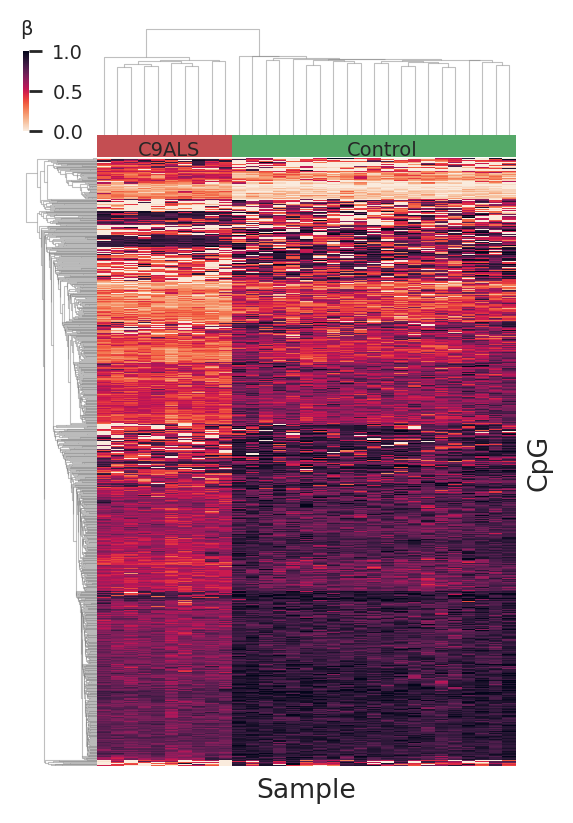

In [101]:
mpl.rcParams['font.family'] = 'Arial'
sns.set(context="paper", style="ticks")

ax = sns.clustermap(
    temp_heatmap_df,
    col_colors=[
        "g" if _.startswith("Control") else "r" for _ in temp_heatmap_df.columns
    ],
    yticklabels=False,
    xticklabels=False,
    cbar_pos=(0.05, 0.83, 0.01, 0.1),
    cmap="rocket_r",
    figsize=(2.95, 4),
    row_cluster=True,
    col_cluster=True,
    dendrogram_ratio=(0.15, 0.15),
)

# --- fade the cluster trees (dendrograms) ---
for ax_ in [ax.ax_row_dendrogram, ax.ax_col_dendrogram]:
    for coll in ax_.collections:  # each is a LineCollection
        coll.set_alpha(0.5)  # transparency: 0 = invisible, 1 = solid
        coll.set_linewidth(0.4)  # (optional) thinner lines
        coll.set_color("gray")  # (optional) softer color
#ax.title.set_fontsize(8)
#ax.xaxis.label.set_fontsize(8)
#ax.yaxis.label.set_fontsize(8)
# optional: tick labels too
ax.tick_params(axis="both", labelsize=7)

ax.ax_cbar.set_title("β",fontsize=7)
ax.ax_heatmap.set_xlabel("Sample")
ax.ax_heatmap.set_ylabel("CpG")


ax.ax_heatmap.text(3, -5, "C9ALS", fontdict={"size": 7})
ax.ax_heatmap.text(18.5, -5, "Control", fontdict={"size": 7})

ax.savefig(
    "./Fig.2B_narrow.png",
    bbox_inches="tight",
    dpi=600,
)

# Fig2C

In [7]:
cell_prop_largeG_u25 = pd.read_csv(
    "./Fig.2C.value.csv",
    index_col=0,
)

<Axes: >

Text(-1.8, -15, '%')

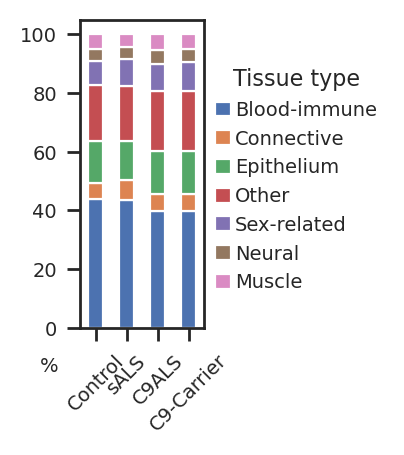

In [79]:
# u25
cell_prop_largeG_mean = (
    cell_prop_largeG_u25.T.groupby(
        [_.split("_")[0] for _ in cell_prop_largeG_u25.columns]
    )
    .mean()
    .T
)
cell_prop_largeG_mean = cell_prop_largeG_mean * 100
cell_prop_largeG_mean = cell_prop_largeG_mean.rename(
    columns={"C9-Patient": "C9ALS"}, index={"Blood immune": "Blood-immune"}
)
cell_prop_largeG_mean = cell_prop_largeG_mean[
    ["Control", "sALS", "C9ALS", "C9-Carrier"]
]

f, ax = plt.subplots(figsize=(0.8, 2))
mpl.rcParams["font.family"] = "Arial"
sns.set(context="paper", style="ticks")
cell_prop_largeG_mean.T.plot(kind="bar", stacked=True, ax=ax)
ax.legend(
    bbox_to_anchor=(0.95, 0.9),
    frameon=False,
    fontsize=7,
    handlelength=0.8,
    handleheight=0.8,
    handletextpad=0.2,
    title="Tissue type",
    title_fontsize=8,
)
ax.tick_params(axis="both", labelsize=7)
ax.tick_params(axis="x", rotation=45)
ax.text(-1.8, -15, "%", fontdict={"size": 7})
f.figure.savefig(
    "./Fig.2C.png",
    bbox_inches="tight",
    dpi=600,
)

<Axes: >

Text(-15, -1.2, '%')

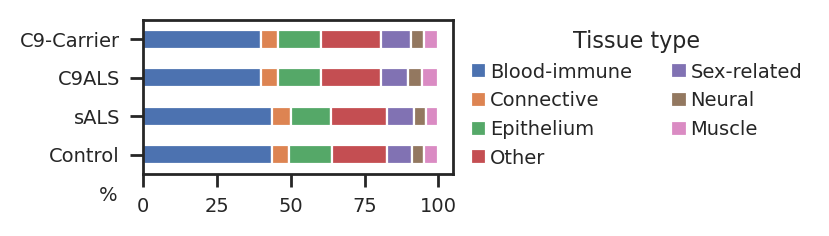

In [94]:
f, ax = plt.subplots(figsize=(2, 1))
sns.set_theme("paper", style="ticks")
cell_prop_largeG_mean.T.plot(kind="barh", stacked=True, ax=ax)
ax.text(-15, -1.2, "%", fontdict={"size": 7})
ax.legend(
    bbox_to_anchor=(1, 1.05),
    frameon=False,
    fontsize=7,
    handlelength=0.8,
    handleheight=0.8,
    handletextpad=0.2,
    title="Tissue type",
    title_fontsize=8,
    ncols=2
)
ax.tick_params(axis="both", labelsize=7)
f.figure.savefig(
    "./Fig.2C.horizontal.png",
    bbox_inches="tight",
    dpi=600,
)